# Bootcamp Sesión 4
### KNN | DBSCAN | Hierarchical Clustering | PCA | 
Septiembre 2024


El **aprendizaje no supervisado** es un tipo de machine learning en el cual el modelo se entrena utilizando datos que no están etiquetados, es decir, no hay una salida esperada para cada instancia en el conjunto de datos. El objetivo del aprendizaje no supervisado es identificar patrones o estructuras ocultas en los datos.

##### Tipos principales de aprendizaje no supervisado:

1. **Clustering (agrupamiento)**: El objetivo es dividir los datos en grupos o "clusters" de manera que los datos en el mismo grupo sean más similares entre sí que a los de otros grupos. Ejemplos de algoritmos de clustering incluyen:
   - **K-Means**
   - **DBSCAN**
   - **Hierarchical Clustering**

2. **Reducción de Dimensionalidad**: Estos métodos buscan reducir el número de variables (o características) en los datos mientras preservan la mayor cantidad de información posible. Se utiliza para simplificar datos complejos y mejorar la visualización o el rendimiento del modelo. Ejemplos incluyen:
   - **PCA (Análisis de Componentes Principales)**
   - **t-SNE**

##### Diferencia clave con el aprendizaje supervisado:
- **Sin etiquetas**: A diferencia del aprendizaje supervisado, en el aprendizaje no supervisado no tenemos etiquetas o resultados correctos con los cuales comparar las predicciones del modelo.En su lugar, el algoritmo trata de descubrir patrones por sí mismo.

##### Aplicaciones comunes:
- **Segmentación de clientes**: Agrupar clientes con características similares.
- **Reducción de ruido en datos**.
- **Análisis de datos de imagen**: Como en la compresión de imágenes.


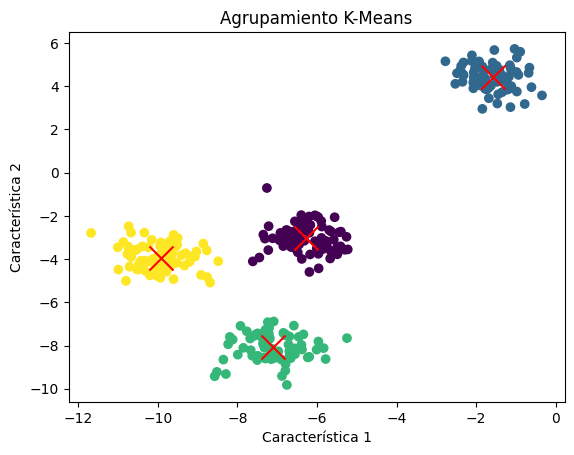

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generar datos aleatorios (blobs) para el ejemplo
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=1)

# Crear el modelo KMeans
kmeans = KMeans(n_clusters=4)  # Elegimos 4 clústeres
kmeans.fit(X)  # Entrenar el modelo

# Obtener los centroides y las etiquetas de clúster
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Graficar los datos con los clústeres
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')

# Graficar los centroides
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='x')  # Los centroides en rojo
plt.title('Agrupamiento K-Means')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()



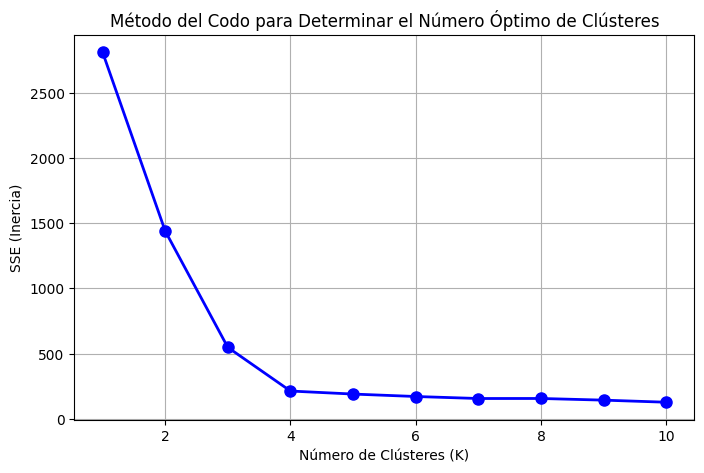

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generar datos aleatorios (blobs) para el ejemplo
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Lista para almacenar la inercia (SSE) para cada valor de K
sse = []

# Probar varios valores de K (número de clústeres)
K_range = range(1, 11)  # Vamos a probar desde 1 hasta 10 clústeres
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # Inercia es la suma de los errores al cuadrado

# Graficar el método del codo
plt.figure(figsize=(8,5))
plt.plot(K_range, sse, 'bo-', linewidth=2, markersize=8)
plt.title('Método del Codo para Determinar el Número Óptimo de Clústeres')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('SSE (Inercia)')
plt.grid(True)
plt.show()


DBSCAN es un algoritmo de agrupamiento (clustering) basado en densidad que es capaz de encontrar clústeres de forma arbitraria y manejar ruido (datos que no pertenecen a ningún clúster). A diferencia de K-Means, no requiere especificar el número de clústeres con antelación.

Número de clústeres encontrados: 8


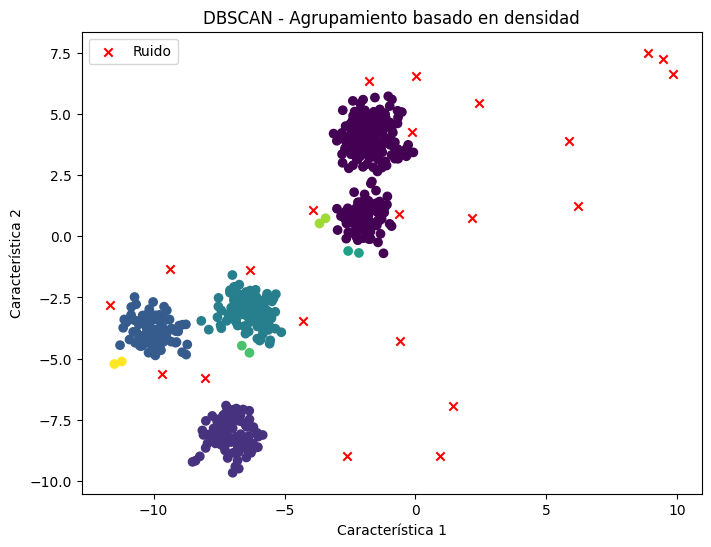

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

# Generar datos aleatorios con ruido
X, y = make_blobs(n_samples=600, centers=6, cluster_std=0.60, random_state=1)

# Añadir algunos puntos de ruido al conjunto de datos
X = np.vstack([X, np.random.uniform(low=-10, high=10, size=(20, 2))])

# Crear el modelo DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=2)

# Ajustar el modelo
dbscan.fit(X)

# Obtener las etiquetas de clúster
labels = dbscan.labels_

# Número de clústeres (ignorar el ruido, etiquetado como -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Número de clústeres encontrados: {n_clusters}")

# Graficar los datos
plt.figure(figsize=(8, 6))
# Puntos que son clústeres
plt.scatter(X[labels != -1][:, 0], X[labels != -1][:, 1], c=labels[labels != -1], cmap='viridis', marker='o')
# Puntos que son ruido
plt.scatter(X[labels == -1][:, 0], X[labels == -1][:, 1], c='red', marker='x', label='Ruido')
plt.title('DBSCAN - Agrupamiento basado en densidad')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.show()


### Clustering Jerárquico (Hierarchical Clustering)

El **clustering jerárquico** es un enfoque de agrupamiento que busca crear una jerarquía de clústeres. A diferencia de otros métodos como K-Means o DBSCAN, no se necesita predefinir el número de clústeres. En lugar de eso, se genera un árbol de decisiones llamado **dendrograma**, que muestra las fusiones o divisiones de los datos en diferentes niveles.

Existen dos enfoques principales para el clustering jerárquico:
1. **Aglomerativo (bottom-up)**: Comienza con cada punto de datos como su propio clúster y, en cada paso, los clústeres más cercanos se fusionan hasta que todos los puntos pertenecen a un único clúster.
2. **Divisivo (top-down)**: Comienza con todos los puntos en un solo clúster, y se divide en subclústeres en cada paso.

#### Distancias en Clustering Jerárquico:
Al fusionar clústeres, es necesario calcular la distancia entre ellos. Los métodos más comunes son:
- **Distancia simple**: La distancia mínima entre dos puntos de diferentes clústeres.
- **Distancia completa**: La distancia máxima entre dos puntos de diferentes clústeres.
- **Promedio**: El promedio de todas las distancias entre los puntos de los dos clústeres.
- **Centroides**: La distancia entre los centroides de los clústeres.


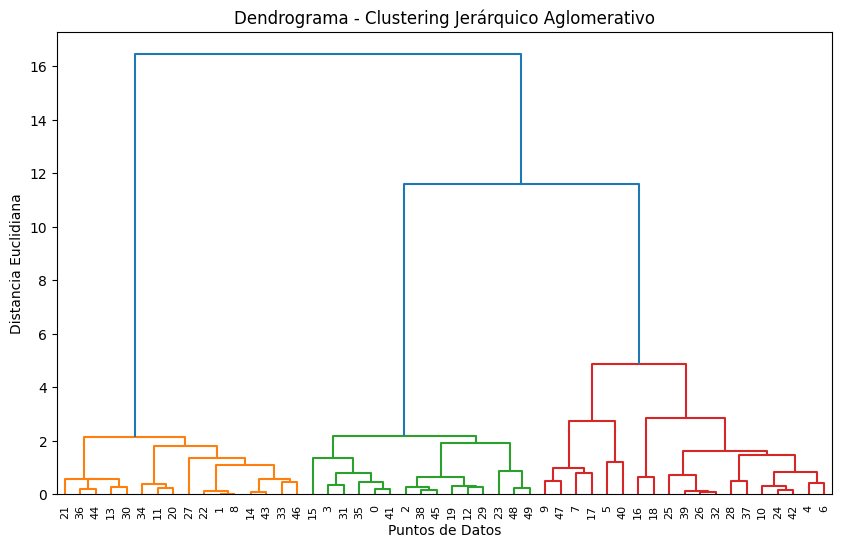

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

# Generar datos de ejemplo
X, y = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=0)

# Aplicar clustering jerárquico (agglomerative) usando la distancia euclidiana
Z = linkage(X, method='ward')

# Crear el dendrograma
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma - Clustering Jerárquico Aglomerativo')
plt.xlabel('Puntos de Datos')
plt.ylabel('Distancia Euclidiana')
plt.show()


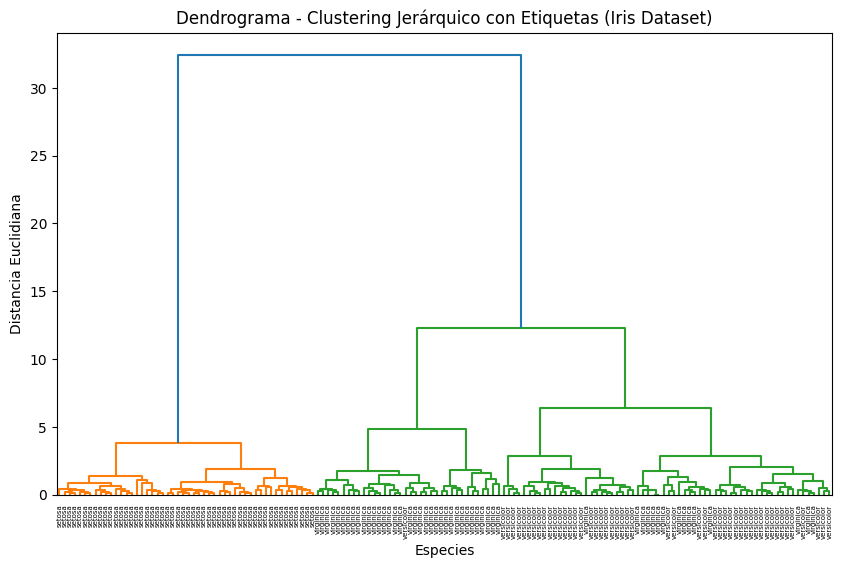

In [5]:
from sklearn.datasets import load_iris
import pandas as pd

# Cargar el dataset Iris
iris = load_iris()
X = iris.data  # Características
species = iris.target  # Etiquetas numéricas de las especies
species_names = [iris.target_names[label] for label in species]  # Nombres de las especies

# Aplicar clustering jerárquico (agglomerative) usando la distancia euclidiana
Z = linkage(X, method='ward')

# Crear el dendrograma con etiquetas (nombres de las especies)
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=species_names)  # Se añaden las etiquetas de las especies
plt.title('Dendrograma - Clustering Jerárquico con Etiquetas (Iris Dataset)')
plt.xlabel('Especies')
plt.ylabel('Distancia Euclidiana')
plt.xticks(rotation=90)  # Rotar las etiquetas para que se vean mejor
plt.show()

### Análisis de Componentes Principales (PCA)

El **Análisis de Componentes Principales (PCA)** es un método de reducción de dimensionalidad ampliamente utilizado en machine learning y análisis de datos. Su objetivo es transformar un conjunto de variables (características) posiblemente correlacionadas en un conjunto más pequeño de variables no correlacionadas llamadas **componentes principales**. Los primeros componentes principales retienen la mayor parte de la variabilidad presente en los datos originales.

### Conceptos Clave:

1. **Varianza**: En PCA, la varianza es una medida clave. El primer componente principal es la dirección en la que los datos muestran la mayor varianza, y los componentes subsiguientes son ortogonales al primero y representan la siguiente mayor cantidad de varianza.
2. **Autovectores y Autovalores**: PCA se basa en el cálculo de los **autovectores** y **autovalores** de la matriz de covarianza de los datos. Los autovectores indican las direcciones de los componentes principales y los autovalores indican la magnitud de la varianza en esas direcciones.
3. **Reducción de dimensionalidad**: Al proyectar los datos sobre los primeros componentes principales, podemos reducir el número de características (dimensiones) manteniendo la mayor parte de la información original. Esto es útil para eliminar el ruido y hacer más eficientes los algoritmos de aprendizaje.

### Proceso de PCA:

1. **Estandarización de los datos**: Normalizar las características para que tengan media 0 y varianza 1 (si las escalas de las características son diferentes).
   
2. **Matriz de covarianza**: Calcular la matriz de covarianza que describe las relaciones entre las características.
   
3. **Autovectores y Autovalores**: Calcular los autovectores y autovalores de la matriz de covarianza. Los autovectores proporcionan las direcciones de los componentes principales y los autovalores proporcionan la varianza explicada en cada dirección.

4. **Selección de componentes principales**: Elegir los primeros \( k \) componentes principales que retienen la mayor parte de la varianza.

5. **Proyección de los datos**: Transformar los datos originales proyectándolos sobre los nuevos componentes principales.

### Ventajas de PCA:

- **Reducción de dimensionalidad**: Reduce el número de características manteniendo la mayor cantidad de información.
- **Elimina la multicolinealidad**: Las nuevas variables (componentes principales) son ortogonales, es decir, no están correlacionadas.
- **Mejora el rendimiento de los modelos**: Al reducir la dimensionalidad, muchos modelos de machine learning se vuelven más rápidos y efectivos.

### Desventajas:

- **Perdida de interpretabilidad**: Las nuevas variables (componentes principales) no tienen un significado intuitivo.
- **Asume linealidad**: PCA encuentra solo relaciones lineales entre las características. No funciona bien si los datos tienen relaciones no lineales complejas.


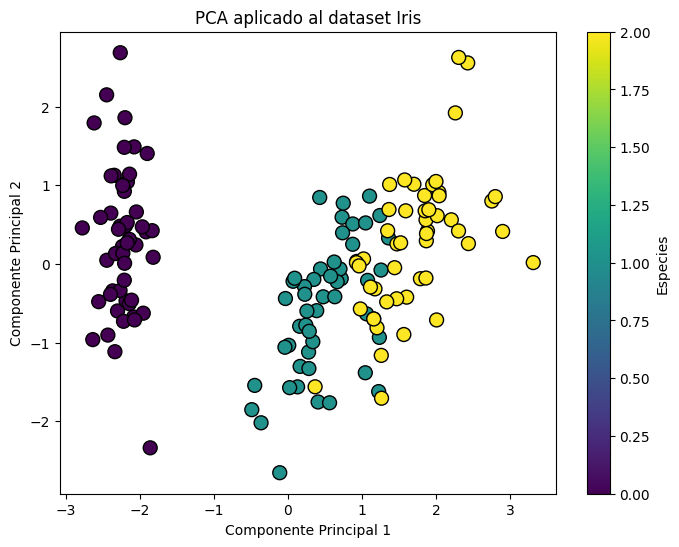

Varianza explicada por cada componente principal: [0.72962445 0.22850762]
Varianza total explicada: 0.9581320720000166


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar el dataset Iris
iris = load_iris()
X = iris.data  # Características
y = iris.target  # Etiquetas (especies de flores)

# Estandarizar los datos (media = 0, varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA para reducir a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar los datos proyectados en las 2 primeras componentes principales
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA aplicado al dataset Iris')
plt.colorbar(label='Especies')
plt.show()

# Variancia explicada por cada componente principal
print("Varianza explicada por cada componente principal:", pca.explained_variance_ratio_)
print("Varianza total explicada:", np.sum(pca.explained_variance_ratio_))


In [20]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

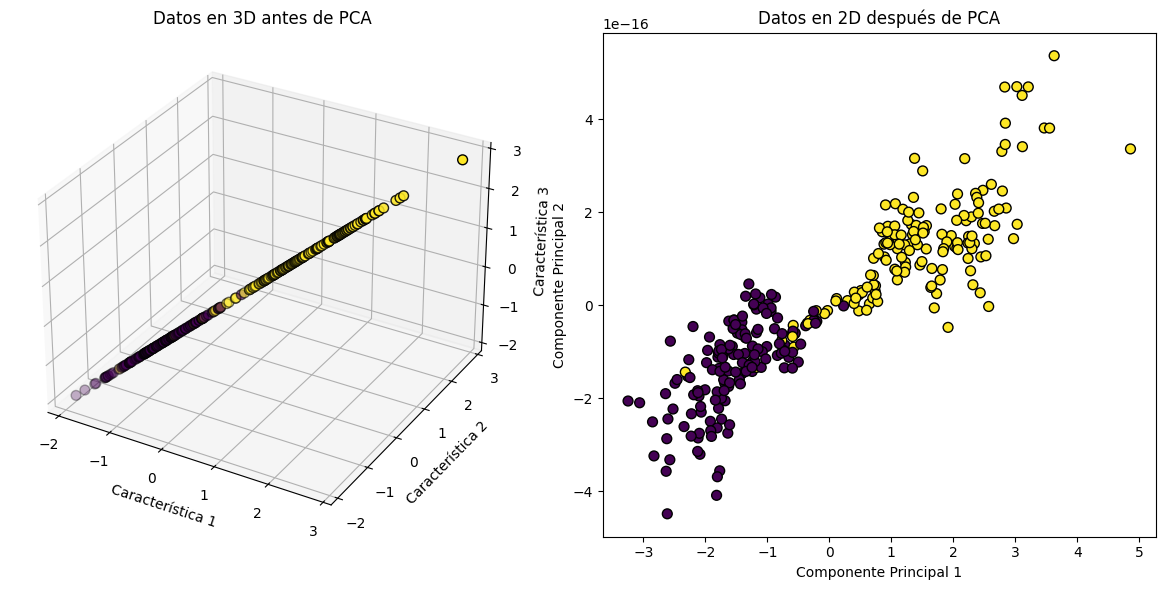

Varianza explicada por cada componente principal: [1.00000000e+00 2.35821892e-17]
Varianza total explicada: 1.0


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

# Generar datos sintéticos en 3D
X, y = make_classification(n_samples=300, n_features=3, n_informative=1, n_clusters_per_class=1, random_state=42)

# Escalar los datos para PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualización de los datos en 3D antes de PCA
fig = plt.figure(figsize=(12, 6))

# Gráfico 3D
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=y, cmap='viridis', edgecolor='k', s=50)
ax.set_title('Datos en 3D antes de PCA')
ax.set_xlabel('Característica 1')
ax.set_ylabel('Característica 2')
ax.set_zlabel('Característica 3')

# Aplicar PCA para reducir de 3 a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Gráfico 2D después de PCA
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
ax2.set_title('Datos en 2D después de PCA')
ax2.set_xlabel('Componente Principal 1')
ax2.set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

# Mostrar la varianza explicada por cada componente
print("Varianza explicada por cada componente principal:", pca.explained_variance_ratio_)
print("Varianza total explicada:", np.sum(pca.explained_variance_ratio_))


In [22]:
def get_full_price_data(ticker,  API_KEY):
    # Crear la URL dinámica con los parámetros de entrada
    url = f'https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}?apikey={API_KEY}'
    
    # Hacer la solicitud GET a la API
    response = requests.get(url)
    
    # Comprobar si la respuesta fue exitosa (status code 200)
    if response.status_code == 200:
        # Convertir la respuesta a formato JSON
        data = response.json()
        df = pd.DataFrame(data['historical'])
        df = df.assign(ticker = f'{ticker}')
        return df
    else:
        # Si hubo un error, devolver el código de error
        print(f"Error: {response.status_code}")
        return None

def get_ticker_data(API_KEY):
    # Crear la URL dinámica con los parámetros de entrada
    url = f'https://financialmodelingprep.com/api/v3/stock/list?apikey={API_KEY}'
    
    # Hacer la solicitud GET a la API
    response = requests.get(url)
    
    # Comprobar si la respuesta fue exitosa (status code 200)
    if response.status_code == 200:
        # Convertir la respuesta a formato JSON
        data = response.json()
        df = pd.DataFrame(data)
        return df
    else:
        # Si hubo un error, devolver el código de error
        print(f"Error: {response.status_code}")
        return None

def get_index_data(API_KEY):
    # Crear la URL dinámica con los parámetros de entrada
    url = f'https://financialmodelingprep.com/api/v3/symbol/available-indexes?apikey={API_KEY}'
    
    # Hacer la solicitud GET a la API
    response = requests.get(url)
    
    # Comprobar si la respuesta fue exitosa (status code 200)
    if response.status_code == 200:
        # Convertir la respuesta a formato JSON
        data = response.json()
        df = pd.DataFrame(data)
        return df
    else:
        # Si hubo un error, devolver el código de error
        print(f"Error: {response.status_code}")
        return None



In [24]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
load_dotenv()

API_KEY = os.environ['FMP']

df_tsla = get_full_price_data('TSLA', API_KEY)

In [25]:
df_tsla

,date,open,high,low,close,adjClose,volume,unadjustedVolume,change,changePercent,vwap,label,changeOverTime,ticker
0,2024-10-16,221.40,222.82,218.93,221.33,221.33,49241536,49241536,-0.07,-0.031617,221.1200,"October 16, 24",-0.000316,TSLA
1,2024-10-15,220.01,224.26,217.12,219.57,219.57,62988787,62988787,-0.44,-0.199990,220.2400,"October 15, 24",-0.002000,TSLA
2,2024-10-14,220.13,221.91,213.74,219.16,219.16,86291923,86291923,-0.97,-0.440650,218.7350,"October 14, 24",-0.004406,TSLA
3,2024-10-11,220.13,223.34,214.38,217.80,217.80,142628900,142628900,-2.33,-1.060000,218.9125,"October 11, 24",-0.010600,TSLA
4,2024-10-10,241.81,242.79,232.34,238.77,238.77,83087100,83087100,-3.04,-1.260000,238.9275,"October 10, 24",-0.012600,TSLA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,2019-10-23,16.97,17.08,16.76,16.98,16.98,78916500,78916500,0.01,0.058928,16.9400,"October 23, 19",0.000589,TSLA
1254,2019-10-22,16.95,17.22,16.72,17.04,17.04,69012000,69012000,0.09,0.530970,16.9900,"October 22, 19",0.005310,TSLA
1255,2019-10-21,17.22,17.30,16.68,16.90,16.90,75304500,75304500,-0.32,-1.860000,16.9600,"October 21, 19",-0.018600,TSLA
1256,2019-10-18,17.38,17.52,17.01,17.13,17.13,86247000,86247000,-0.25,-1.440000,17.2200,"October 18, 19",-0.014400,TSLA


In [26]:
index = get_index_data(API_KEY)

In [27]:
index

,symbol,name,currency,stockExchange,exchangeShortName
0,^TTIN,S&P/TSX Capped Industrials Index,CAD,Toronto Stock Exchange,INDEX
1,^TTCD,S&P/TSX Capped Consumer Discretionary,CAD,Toronto Stock Exchange,INDEX
2,DE000SLA30S3.SG,Solactive Equal Weight Canada Oil & Gas Index,EUR,Stuttgart,INDEX
3,SX7E.Z,STOXX Banks (EUR),EUR,Zurich,INDEX
4,^NYA,NYSE Composite,USD,New York Stock Exchange,INDEX
...,...,...,...,...,...
187,^AMZ,Alerian MLP Index,USD,New York Stock Exchange,INDEX
188,XU100.IS,BIST 100,TRY,Istanbul Stock Exchange,INDEX
189,^AORD,All Ordinaries,AUD,Australian Securities Exchange,INDEX
190,^GDAXI,DAX PERFORMANCE-INDEX,EUR,Deutsche Borse Xetra,INDEX


In [28]:
tickers = get_ticker_data(API_KEY)
tickers

,symbol,name,price,exchange,exchangeShortName,type
0,PMGOLD.AX,Perth Mint Gold,17.9400,Australian Securities Exchange,ASX,etf
1,TCLNX,TIAA-CREF Lifecycle 2030 Fund Retirement Class,15.8200,NASDAQ,NASDAQ,trust
2,TQMIX,AMG TimesSquare Mid Cap Growth Fund Class I,18.6500,NASDAQ,NASDAQ,trust
3,TSCIX,AMG TimesSquare Small Cap Growth Fund,13.8100,NASDAQ,NASDAQ,trust
4,TSCPX,AMG TimesSquare Small Cap Growth Fund Class N,12.8200,NASDAQ,NASDAQ,trust
...,...,...,...,...,...,...
84165,MDNWF,Mednow Inc.,0.0200,Other OTC,PNK,stock
84166,SCT.DE,SSE PLC,23.0000,Frankfurt Stock Exchange,XETRA,stock
84167,HALO.NE,Halo Collective Inc.,0.0200,NEO,NEO,stock
84168,STA.L,Star Phoenix Group Ltd,1.0500,London Stock Exchange,LSE,stock


In [29]:
tickers[tickers.name.fillna('').str.contains('Berk')]

,symbol,name,price,exchange,exchangeShortName,type
1498,BKY.AX,Berkeley Energia Limited,0.3350,Australian Securities Exchange,ASX,stock
3347,BFOCX,Berkshire Focus Fund,26.7800,NASDAQ,NASDAQ,trust
5783,BRK-A,Berkshire Hathaway Inc.,699413.0000,New York Stock Exchange,NYSE,stock
5825,BRK-B,Berkshire Hathaway Inc.,465.6900,New York Stock Exchange,NYSE,stock
6186,WRB-PE,W. R. Berkley Corporation 5.70% SB DB 2058,25.2600,New York Stock Exchange,NYSE,stock
6733,WRB,W. R. Berkley Corporation,59.2800,New York Stock Exchange,NYSE,stock
7737,BHLB,"Berkshire Hills Bancorp, Inc.",28.2700,New York Stock Exchange,NYSE,stock
15332,BRK.NE,Berkshire Hathaway Inc.,35.2100,NEO,NEO,stock
16619,BKGFY,The Berkeley Group Holdings plc,12.6400,Other OTC,PNK,stock
16855,WRB-PF,W.R. Berkley Corporation 5.10%,23.6850,New York Stock Exchange,NYSE,stock


In [30]:
index[index.name.str.contains('500')]

,symbol,name,currency,stockExchange,exchangeShortName
17,^W5000,Wilshire 5000 Total Market Index,USD,New York Stock Exchange,INDEX
35,^SPX,S&P 500 Index,USD,SNP,INDEX
61,^SP500-55,S&P 500 Utilities (Sector),USD,SNP,INDEX
62,^SP500TR,S&P 500 Total Return,USD,SNP,INDEX
63,^SP500-60,S&P 500 Real Estate (Sector),USD,SNP,INDEX
64,^XSP,S&P 500 Mini SPX Options Index,USD,Chicago Options,INDEX
65,^SP500-15,S&P 500 Materials (Sector),USD,SNP,INDEX
66,^SP500-45,S&P 500 Information Technology (Sector),USD,SNP,INDEX
67,^SP500-20,S&P 500 Industrials (Sector),USD,SNP,INDEX
68,^SP500-35,S&P 500 Health Care (Sector),USD,SNP,INDEX


In [31]:
df_sp500 = get_full_price_data('^GSPC',API_KEY)

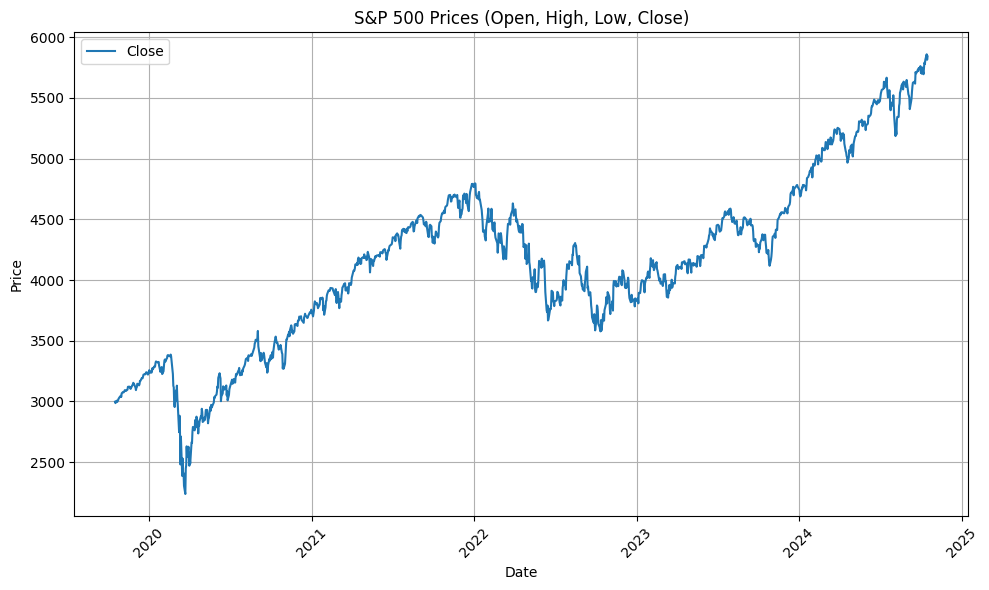

In [32]:
import pandas as pd
import matplotlib.pyplot as plt


df_sp500['date'] = pd.to_datetime(df_sp500['date'])

# Graficar los precios de apertura, cierre, máximo y mínimo
plt.figure(figsize=(10, 6))
#plt.plot(df_sp500['date'], df_sp500['open'], marker='o', label='Open')
#plt.plot(df_sp500['date'], df_sp500['high'], marker='o', label='High')
#plt.plot(df_sp500['date'], df_sp500['low'], marker='o', label='Low')
plt.plot(df_sp500['date'], df_sp500['close'], label='Close')

# Configurar el gráfico
plt.title('S&P 500 Prices (Open, High, Low, Close)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [33]:
tickers = ['MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'BRK-B', 'LLY', 'TSLA', 'AVGO', 'WMT']

all_data = pd.DataFrame()

for ticker in tickers:
    print(ticker)
    df = get_full_price_data(ticker, API_KEY)  # Asumimos que esta función ya está definida
    df = df[['date', 'close']].set_index('date')  # Solo tomamos la columna de fecha, cierre y ticker
    if all_data.empty:
        all_data = df
    else:
        all_data = pd.concat([all_data, df], axis=1)

MSFT
NVDA
GOOGL
AMZN
META
BRK-B
LLY
TSLA
AVGO
WMT


In [34]:
all_data.columns = tickers

In [35]:
all_data.head()

,MSFT,NVDA,GOOGL,AMZN,META,BRK-B,LLY,TSLA,AVGO,WMT
date,,,,,,,,,,
2024-10-16,416.12,135.72,165.14,186.90,576.79,465.69,916.42,221.33,176.88,81.23
2024-10-15,418.74,131.60,165.46,187.69,586.27,462.68,913.32,219.57,175.98,81.65
2024-10-14,419.14,138.07,164.96,187.54,590.42,459.98,929.51,219.16,182.31,80.29
2024-10-11,416.32,134.80,163.24,188.82,589.95,460.21,932.06,217.80,181.48,80.10
2024-10-10,415.84,134.81,162.08,186.65,583.83,454.93,910.69,238.77,185.69,79.61


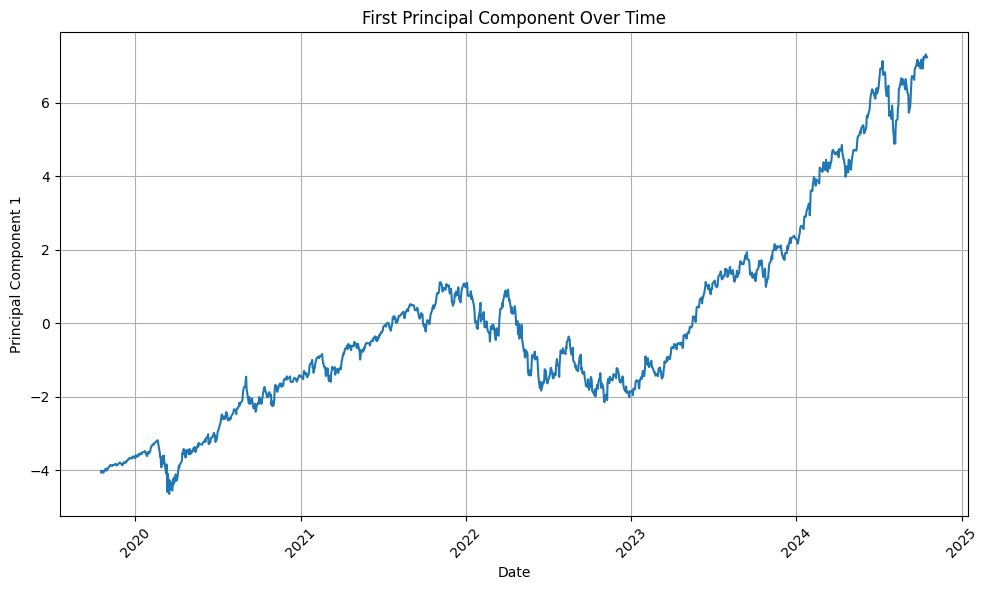

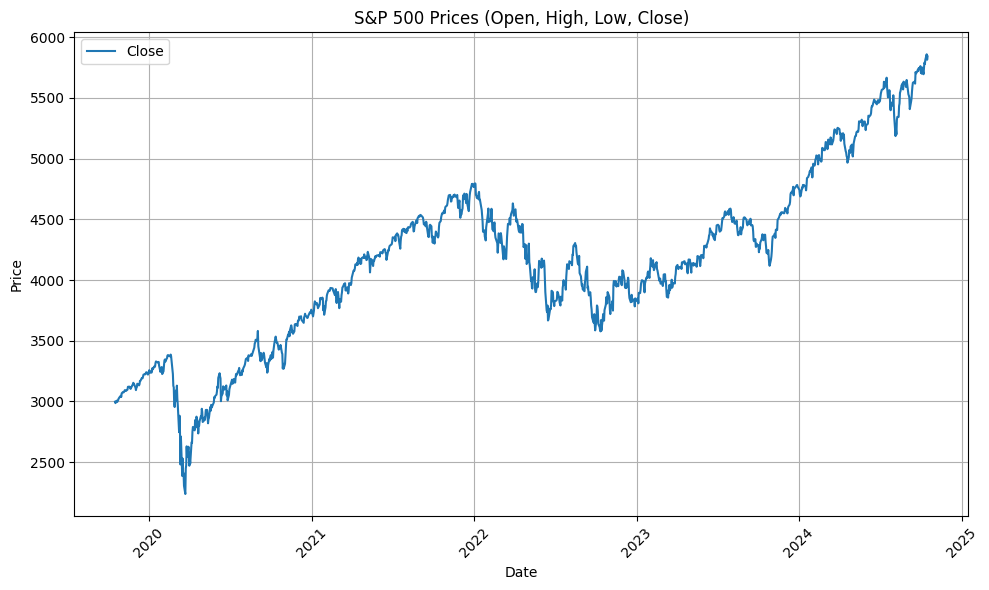

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Aplicar el PCA y graficar el primer componente a través del tiempo
scaler = StandardScaler()
df_scaled = scaler.fit_transform(all_data)

# Aplicar PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

# Crear un DataFrame con el primer componente
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=all_data.index)

# Graficar el primer componente a través del tiempo
# Reordenamos el PCA usando [::-1]
plt.figure(figsize=(10, 6))
plt.plot(df_sp500['date'][::-1], df_pca['PC1'][::-1], label='PC1')
plt.title('First Principal Component Over Time')
plt.xlabel('Date')
plt.ylabel('Principal Component 1')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



df_sp500['date'] = pd.to_datetime(df_sp500['date'])

# Graficar los precios de apertura, cierre, máximo y mínimo
plt.figure(figsize=(10, 6))
#plt.plot(df_sp500['date'], df_sp500['open'], marker='o', label='Open')
#plt.plot(df_sp500['date'], df_sp500['high'], marker='o', label='High')
#plt.plot(df_sp500['date'], df_sp500['low'], marker='o', label='Low')
plt.plot(df_sp500['date'], df_sp500['close'], label='Close')

# Configurar el gráfico
plt.title('S&P 500 Prices (Open, High, Low, Close)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<Axes: xlabel='date'>

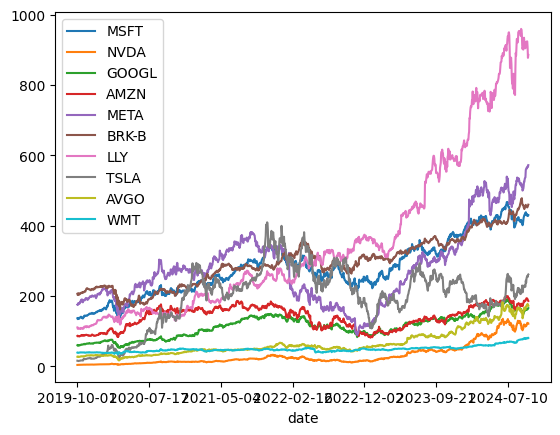

In [97]:
all_data[::-1].plot(kind='line')

In [98]:
health_industry = get_full_price_data('^SP500-35', API_KEY)

<Axes: xlabel='date'>

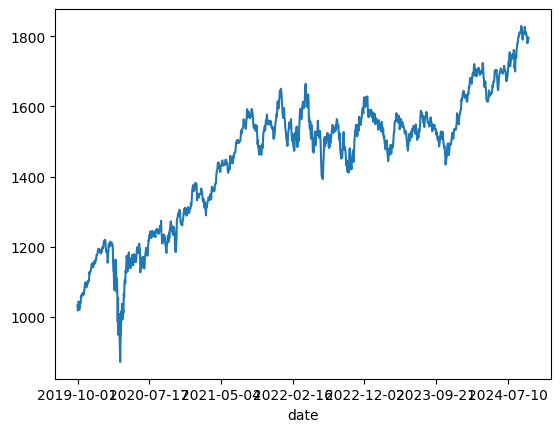

In [101]:
health_industry.set_index('date')['close'][::-1].plot(kind='line')

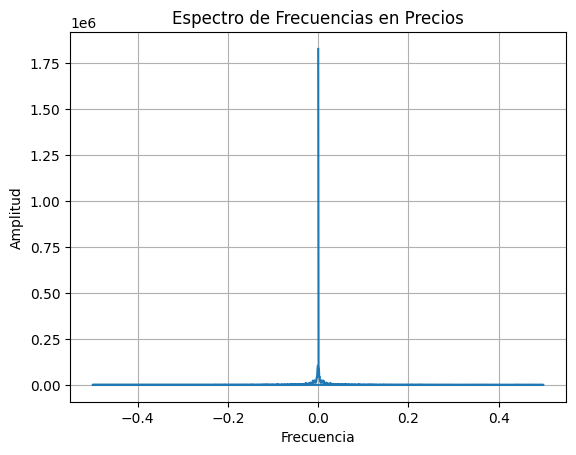

In [102]:

# Aplicar la Transformada de Fourier
fft = np.fft.fft(health_industry['close'])
frecuencias = np.fft.fftfreq(len(fft))

# Graficar el espectro de frecuencias
plt.plot(frecuencias, np.abs(fft))
plt.title('Espectro de Frecuencias en Precios')
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

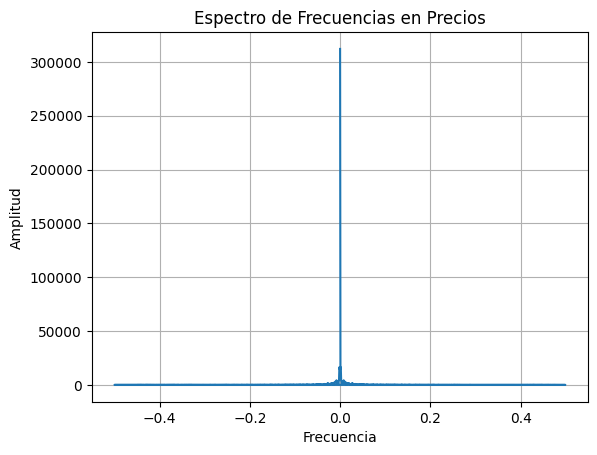

In [105]:
tsla = get_full_price_data('^SP500-60', API_KEY)

# Aplicar la Transformada de Fourier
fft = np.fft.fft(tsla['close'])
frecuencias = np.fft.fftfreq(len(fft))

# Graficar el espectro de frecuencias
plt.plot(frecuencias, np.abs(fft))
plt.title('Espectro de Frecuencias en Precios')
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

El resultado que ves, con un pico dominante cercano a la frecuencia cero, es bastante típico cuando se aplica la Transformada de Fourier (FFT) a series temporales financieras, como los precios de activos.

1. Frecuencia Cero (Componente de Frecuencia Baja):
El pico cercano a la frecuencia cero sugiere que la mayor parte de la variabilidad en los precios está relacionada con tendencias de largo plazo o un componente constante. Esto significa que hay una tendencia general o un "nivel base" en los precios.
En términos de la señal, la frecuencia cero indica que hay un valor promedio que domina la serie temporal. Es decir, no hay oscilaciones rápidas o patrones cíclicos de alta frecuencia que contribuyan significativamente a los movimientos de los precios.

2. Frecuencias Mayores:
Las frecuencias más alejadas de cero representan fluctuaciones más rápidas o patrones de corto plazo. En este caso, dado que la mayoría de la energía (amplitud) está concentrada en la frecuencia cero, no hay componentes significativos que representen ciclos o variaciones rápidas en los precios.
La falta de picos alejados de la frecuencia cero sugiere que los precios no están dominados por fluctuaciones rápidas, lo que significa que los cambios en los precios son más suaves y no tienen ciclos o patrones repetitivos claros en el corto plazo.

3. Interpretación General:
Un solo pico en la frecuencia cero indica una tendencia más constante en los precios, sin grandes oscilaciones rápidas o repetitivas.
En el contexto de los mercados financieros, las series de precios suelen tener una fuerte componente en la frecuencia cero, ya que los precios de las acciones tienden a seguir una tendencia más suave a lo largo del tiempo, sin muchos patrones cíclicos repetitivos en escalas pequeñas.
Si el espectro de frecuencias mostrara varios picos alejados de cero, eso indicaría la presencia de patrones cíclicos o de variaciones periódicas en los datos, algo más común en señales físicas o económicas que sigan un comportamiento repetitivo (como ventas estacionales, etc.).

https://github.com/firmai/deltapy/tree/master

https://arxiv.org/abs/2104.07406


## Introduction
### Tabular Augmentation


Tabular augmentation is a new experimental space that makes use of novel and traditional data generation and synthesisation techniques to improve model prediction success. It is in essence a process of modular feature engineering and observation engineering while emphasising the order of augmentation to achieve the best predicted outcome from a given information set. DeltaPy was created with finance applications in mind, but it can be broadly applied to any data-rich environment.

To take full advantage of tabular augmentation for time-series you would perform the techniques in the following order: (1) transforming, (2) interacting, (3) mapping, (4) extracting, and (5) synthesising. What follows is a practical example of how the above methodology can be used. The purpose here is to establish a framework for table augmentation and to point and guide the user to existing packages.

In [37]:
nvda = get_full_price_data('NVDA', API_KEY)
intel = get_full_price_data('INTC', API_KEY)

In [47]:
nvda['date'] = pd.to_datetime(nvda['date'])
intel['date'] = pd.to_datetime(intel['date'])

<Axes: xlabel='date'>

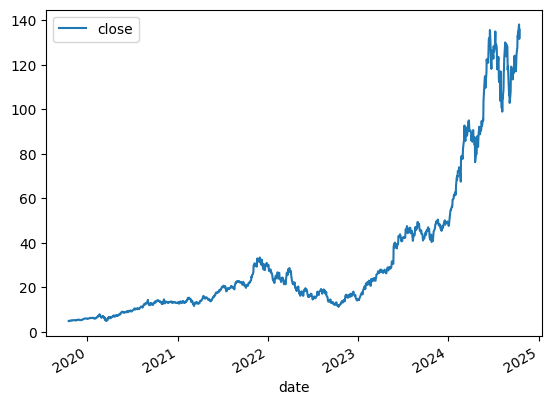

In [43]:
nvda[['date','close']].set_index('date').plot(kind='line')

<Axes: xlabel='date'>

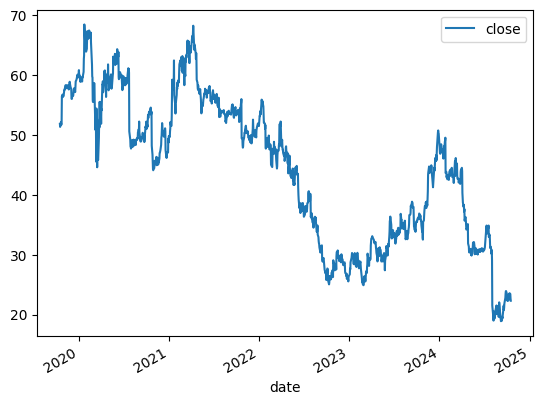

In [48]:
intel[['date','close']].set_index('date').plot(kind='line')